In [ ]:
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Variation in the signal at time contributes strongly to discriminating the two conditions, conditional on all other time points.
#Positive → Higher values at time increase the log-odds of class 1
#Negative → Higher values at time increase the log-odds of class 2

In [ ]:
# fake data must be 48, 177 sample*time(features), label = 48 of 1 or 2
X = np.random.normal(size=(4, 177)) 
y_true= np.random.choice([0, 1], 4)
col = {0:'b', 1:'r'}

# PCA data
X = pd.read_csv('/Users/barbaragrosjean/Documents/MIB/MIB_iEEG/outs/grpPCA/supsubj_concat/grp_concat_Xtrans_PCA3.csv').query('freq == "high_gamma" and compo == "compo1"').drop(columns = ['freq', 'compo', 'subj', 'expl_var', 'Unnamed: 0' ]).values
X = np.concat([X[:, :int(X.shape[1]/2)], X[:, int(X.shape[1]/2):]], axis=0)
y_true = [0, 1]

In [136]:
clf = LogisticRegression()
clf.fit(X, y_true)
y_pred = clf.predict(X)

In [146]:
from scipy.special import expit  # sigmoid

w = clf.coef_[0]          # (n_features,)
b = clf.intercept_[0]

# Mean feature profile (can be class-specific if you want)
x_mean = X.mean(axis=0)

# Logistic prediction per feature
p_theta = expit(w * x_mean + b)   # shape: (n_features,)


In [151]:
p_theta.shape

(177,)

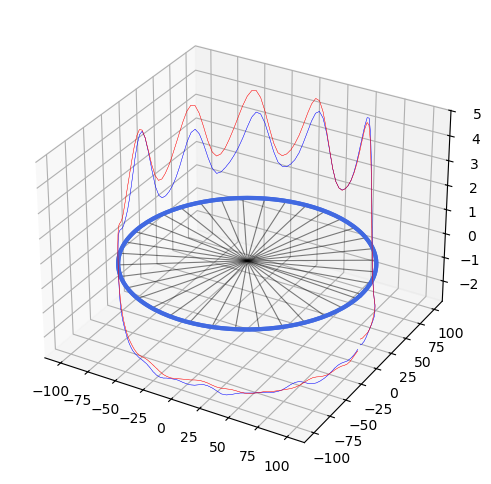

In [155]:
theta = np.linspace(0, 2 * np.pi, X.shape[1], endpoint=False) # time point number of angle
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
r=100
for th in theta[::5]:
    x = [0, r*np.cos(th)]
    y = [0, r*np.sin(th)]
    ax.plot(x, y, color='black', linewidth=0.8, alpha=0.5)
ax.plot(r*np.cos(theta), r*np.sin(theta), 0, c='black', linewidth=0.5, alpha=0.5)

for ia in range(X.shape[0]) : # iterate over the sample
    x = []
    y=[]
    ampl =[]
    for i, t in enumerate(theta) : #iterat over the time point
        x.append(r*np.cos(t))
        y.append(r*np.sin(t))
        ampl.append(X[ia, i])

    ax.plot(x, y, expit(w * ampl + b), color='royalblue',linewidth=3,label='Mean logistic prediction')
    ax.plot(x, y, ampl, c=col[y_true[ia]], linewidth =0.3 )
    ax.plot(x, y, ampl, c=col[y_pred[ia]], linewidth =0.3, ls=':' )

In [168]:
X = np.array([[0.3,0.5],
     [0.2, 0.5],
     [0.7,0.5],
     [0.8, 0.4]])
     
y_true = [0, 0, 1, 1]
clf = LogisticRegression()
clf.fit(X, y_true)
y_pred = clf.predict(X)

w = clf.coef_[0]          
b = clf.intercept_[0]


/var/folders/rr/sx7rgrrj3p12hz70crvxqcjc0000gn/T/ipykernel_8122/1882245318.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([i for i, lab in enumerate(ax.get_xticklabels())])


[Text(0.0, 0, '0'),
 Text(0.7853981633974483, 0, '1'),
 Text(1.5707963267948966, 0, '2'),
 Text(2.356194490192345, 0, '3'),
 Text(3.141592653589793, 0, '4'),
 Text(3.9269908169872414, 0, '5'),
 Text(4.71238898038469, 0, '6'),
 Text(5.497787143782138, 0, '7')]

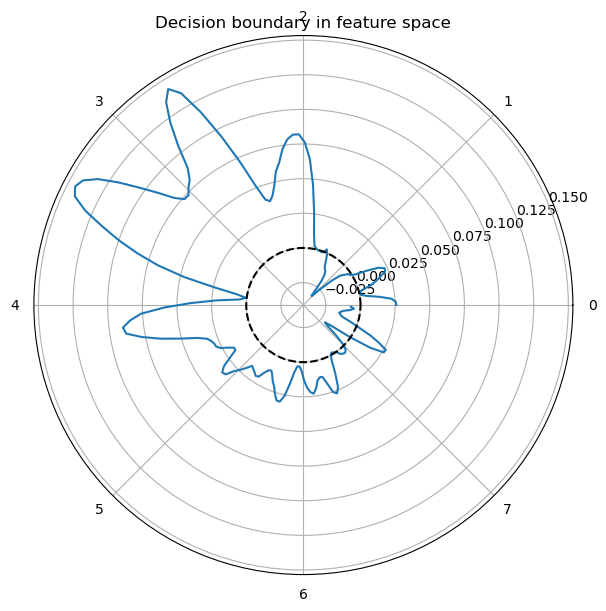

In [ ]:
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(7, 7))

ax.plot(theta, clf.coef_[0], label='Weights')
ax.axhline(0, linestyle='--', color='black', label='Decision boundary')

ax.set_title('Decision boundary in feature space')
ax.set_xticklabels([i for i,_ in enumerate(ax.get_xticklabels())])